In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("smartcart_customers.csv")
df.shape

(2240, 22)

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

Data Pre-processing

df[]

1.Handling missing values


In [6]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [7]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

2.Feature-engineering


In [8]:
df["Age"]=2026-df["Year_Birth"]

In [9]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [10]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

In [11]:
reference_date=df["Dt_Customer"].max()
reference_date

Timestamp('2014-06-29 00:00:00')

In [12]:
df["Customer_Tenure_Days"]=reference_date-df["Dt_Customer"]

In [13]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663 days
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113 days
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312 days
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139 days
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161 days


In [14]:
df["Total_Spending"]=df["MntWines"]+df["MntFruits"]++df["MntMeatProducts"]+df["MntFishProducts"]+ df["MntSweetProducts"]+df["MntGoldProds"]    
   

In [15]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663 days,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113 days,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312 days,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139 days,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161 days,422


In [16]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [17]:
df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "PhD":"Postgraduate","Master":"Postgraduate",
})

In [18]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [19]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [20]:
df["Marital_Status"]=df["Marital_Status"].replace({
    "Married":"Married","Together":"Married",
    "Single":"Not Married","Divorced":"Not Married","Widow":"Not Married","Alone":"Not Married","Absurd":"Not Married","YOLO":"Not Married"
})

In [21]:
df["Marital_Status"].value_counts()
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days',
       'Total_Spending'],
      dtype='object')

In [22]:
df["Total_kids"]=df["Kidhome"]+df["Teenhome"]

In [26]:
cols=["ID","Year_Birth","Dt_Customer","Kidhome","Teenhome"]
spending_cols=['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']

col_drop=cols+spending_cols

df_cleaned=df.drop(columns=col_drop)

In [27]:
df_cleaned.shape

(2240, 15)

In [28]:
df_cleaned.columns

Index(['Education', 'Marital_Status', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_kids'],
      dtype='object')

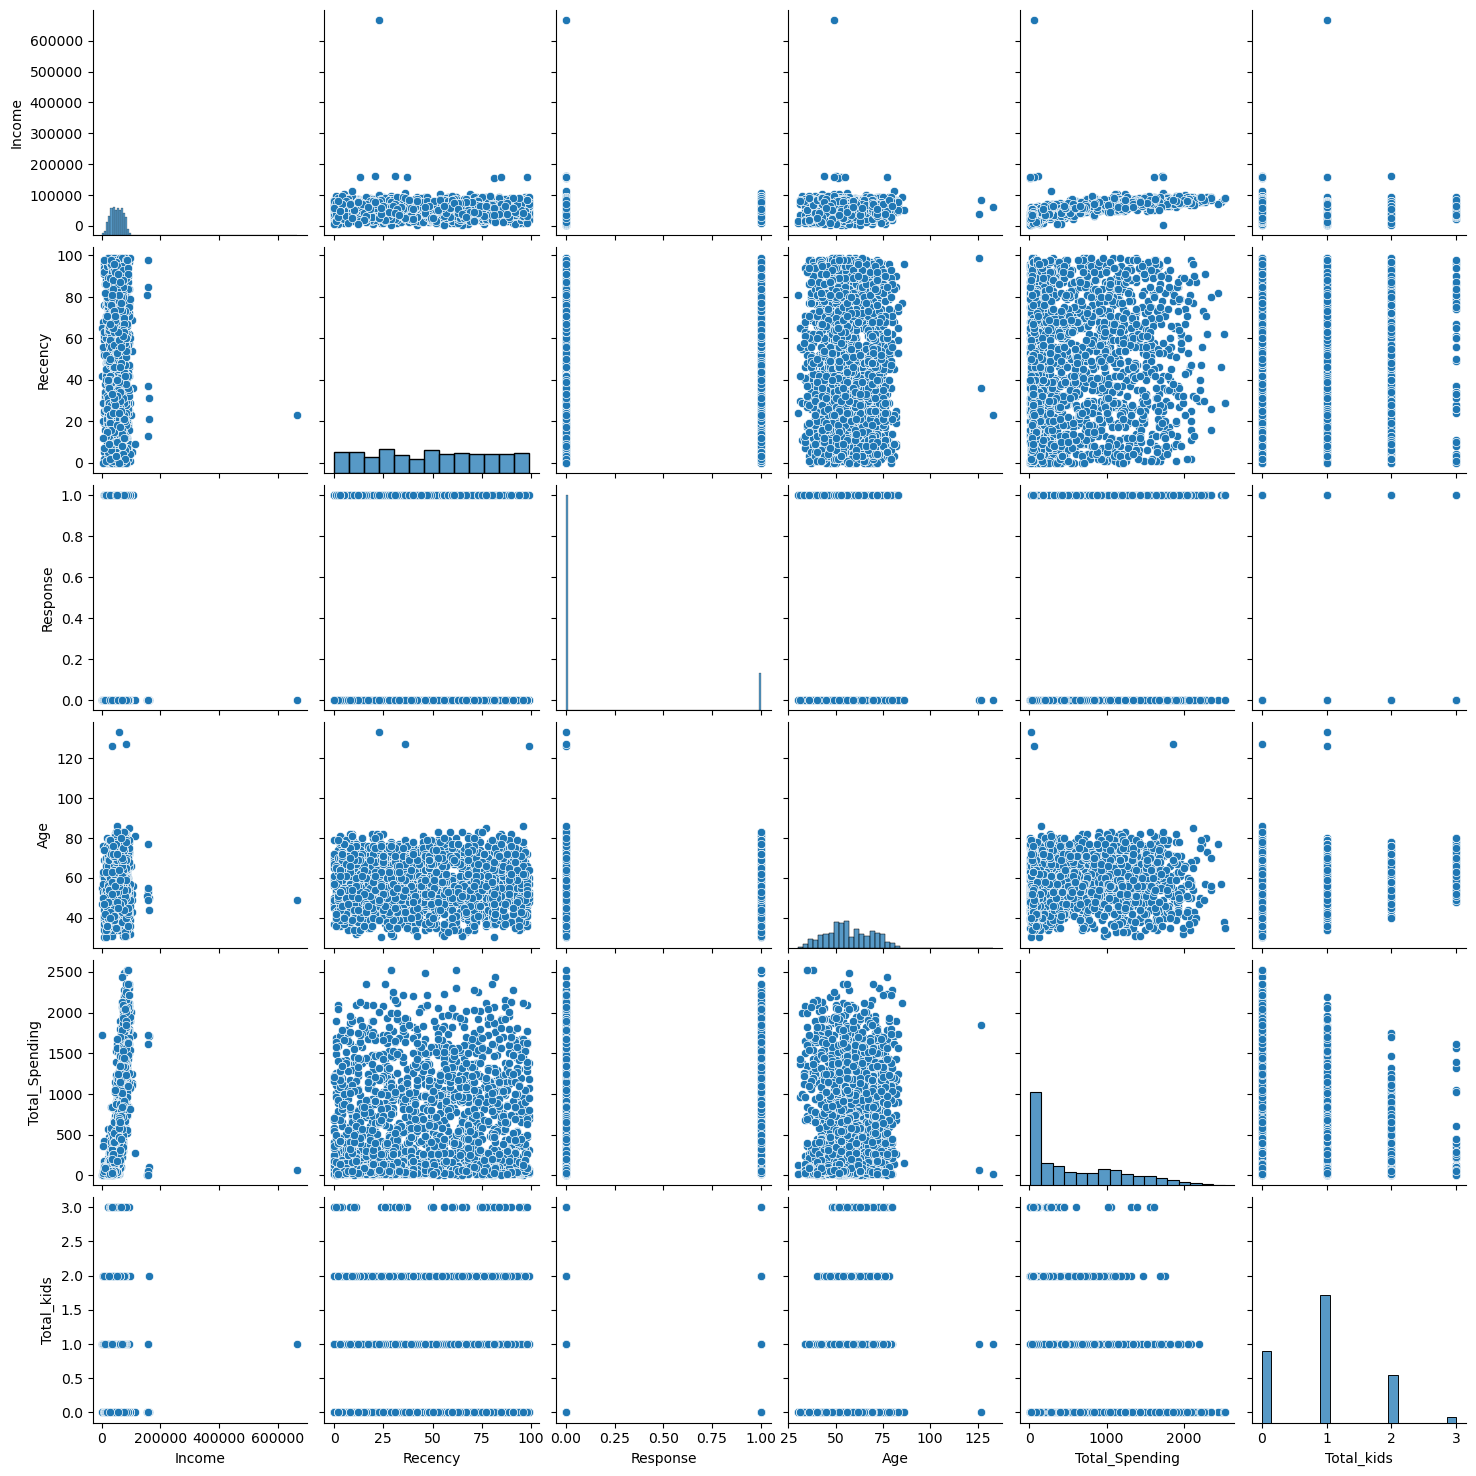

In [29]:
cols=["Income","Recency","Response","Age","Total_Spending","Total_kids"]

sns.pairplot(df_cleaned[cols])

In [32]:
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600000)]

#Heatmap

In [33]:
corr=df_cleaned.corr(numeric_only=True)

In [34]:
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Total_Spending,Total_kids
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,0.113618,0.095512


<Axes: >

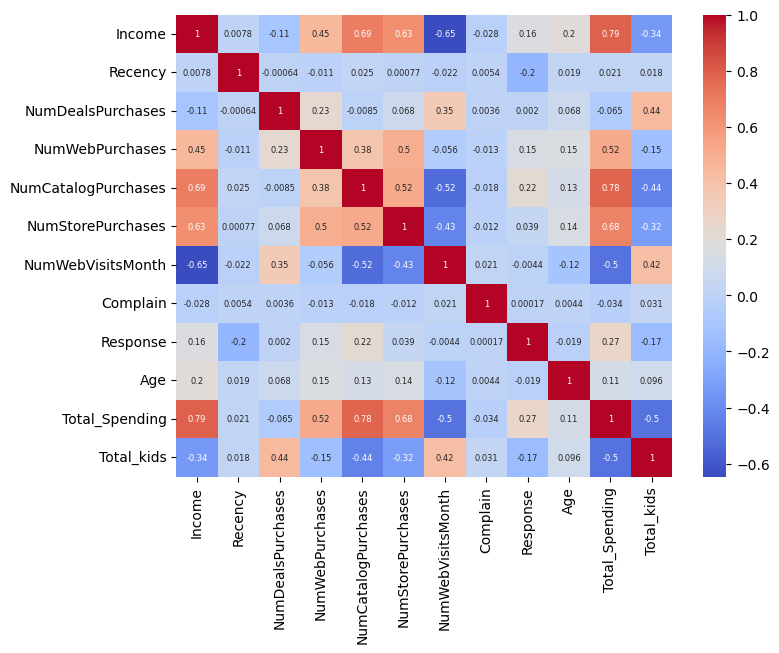

In [37]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

#Encoding

In [38]:
from sklearn.preprocessing import OneHotEncoder

In [40]:
ohe=OneHotEncoder()

cat_cols=["Education","Marital_Status"]

enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [43]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [44]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Marital_Status_Married,Marital_Status_Not Married
0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,1.0,0.0


In [45]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [46]:
df_encoded.shape

(2236, 18)

In [47]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_kids,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Marital_Status_Married,Marital_Status_Not Married
0,58138.0,58,3,8,10,4,7,0,1,69,663 days,1617,0,1.0,0.0,0.0,0.0,1.0
1,46344.0,38,2,1,1,2,5,0,0,72,113 days,27,2,1.0,0.0,0.0,0.0,1.0
2,71613.0,26,1,8,2,10,4,0,0,61,312 days,776,0,1.0,0.0,0.0,1.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,42,139 days,53,1,1.0,0.0,0.0,1.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,161 days,422,1,0.0,1.0,0.0,1.0,0.0


In [52]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X=df_encoded
print(X.dtypes)

Income                                float64
Recency                                 int64
NumDealsPurchases                       int64
NumWebPurchases                         int64
NumCatalogPurchases                     int64
NumStorePurchases                       int64
NumWebVisitsMonth                       int64
Complain                                int64
Response                                int64
Age                                     int64
Customer_Tenure_Days          timedelta64[ns]
Total_Spending                          int64
Total_kids                              int64
Education_Graduate                    float64
Education_Postgraduate                float64
Education_Undergraduate               float64
Marital_Status_Married                float64
Marital_Status_Not Married            float64
dtype: object


In [53]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_kids,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Marital_Status_Married,Marital_Status_Not Married
0,58138.0,58,3,8,10,4,7,0,1,69,663 days,1617,0,1.0,0.0,0.0,0.0,1.0
1,46344.0,38,2,1,1,2,5,0,0,72,113 days,27,2,1.0,0.0,0.0,0.0,1.0
2,71613.0,26,1,8,2,10,4,0,0,61,312 days,776,0,1.0,0.0,0.0,1.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,42,139 days,53,1,1.0,0.0,0.0,1.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,161 days,422,1,0.0,1.0,0.0,1.0,0.0


In [54]:
X['Customer_Tenure_Days'] = X['Customer_Tenure_Days'].dt.days

In [55]:
x_scaled=scaler.fit_transform(X)